<a href="https://colab.research.google.com/github/reali-705/projeto-de-algoritmos-2/blob/main/ProjAlgoritmosII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from graphviz import Digraph
import time
import string
from IPython.display import display, clear_output, HTML
#simbolo gráfico para o epsilon
EPS = "ε"
def _html_palavra_com_cursor(palavra, idx):
    if idx < 0 or idx >= len(palavra):
        return HTML(f"<div style='font-family: monospace; font-size: 16px;'><code>{palavra}</code></div>")
    antes = palavra[:idx]
    atual = palavra[idx]
    depois = palavra[idx+1:]
    html = (
        "<div style='font-family: monospace; font-size:16px; margin-bottom:8px;'>"
        f"<code>{antes}</code>"
        f"<span style='color: darkred; font-weight:700; background:#fff3f3; padding:2px 4px; border-radius:3px;'>{atual}</span>"
        f"<code>{depois}</code>"
        "</div>"
    )
    return HTML(html)


def animar(automato, texto, delay=0.8):
    """
    Função de animação utilizada para cada todas as classes individuais
    de autômatos.
    Parâmetros:
      - automato: autômato a ser animado
      - texto: string a ser lida (cada caractere = um passo)
      - delay: segundos entre frames.
    """
    # Se o autômato oferece epsilon_fecho, use-a; senão, ignore.
    usa_epsilon = hasattr(automato, "epsilon_fecho")

    if usa_epsilon:
        atuais = automato.epsilon_fecho({automato.initial_state})
    else:
        atuais = {automato.initial_state}

    # loop de leitura (um frame por caractere)
    for idx, caractere in enumerate(texto):
        g = Digraph(format='png')

        # desenhar estados
        for s in automato.states:
            attrs = {}
            if s in automato.final_states:
                attrs["shape"] = "doublecircle"
            if s == automato.initial_state:
                # borda azul para inicial
                attrs["color"] = "blue"
            if s in atuais:
                attrs["style"] = "filled"
                attrs["fillcolor"] = "lightgreen"
            # se attrs vazio, Digraph aceita {}
            g.node(str(s), **attrs)

        # desenhar transições e marcar em vermelho as usadas neste passo
        novos = set()
        for (orig, simb), destinos in automato.delta.items():
            for d in destinos:
                cor = "black"
                # marcamos a transição quando a origem está ativa e o símbolo combina
                if orig in atuais and simb in (caractere, "Σ"):
                    cor = "red"
                    novos.add(d)
                # transição ε em cinza
                if simb == EPS:
                    cor = "gray"
                g.edge(str(orig), str(d), label=simb, color=cor)

        # render
        clear_output(wait=True)
        display(_html_palavra_com_cursor(texto, idx))
        display(HTML(f"<div style='font-family:monospace; color:#666; margin-bottom:6px;'>Lendo índice {idx} → '{caractere}'</div>"))
        display(g)

        # atualizar estados ativos
        if usa_epsilon:
            atuais = automato.epsilon_fecho(novos)
        else:
            atuais = novos

        time.sleep(delay)

    # frame final
    clear_output(wait=True)
    display(_html_palavra_com_cursor(texto, len(texto)-1 if texto else 0))
    display(HTML("<div style='font-family:monospace; color:#666; margin-bottom:6px;'>Fim da leitura</div>"))

    # desenha grafo final
    g = Digraph()
    for s in automato.states:
        attrs = {}
        if s in automato.final_states:
            attrs["shape"] = "doublecircle"
        if s == automato.initial_state:
            attrs["color"] = "blue"
        if s in atuais:
            attrs["style"] = "filled"
            attrs["fillcolor"] = "lightgreen"
        g.node(str(s), **attrs)
    for (orig, simb), destinos in automato.delta.items():
        for d in destinos:
            g.edge(str(orig), str(d), label=simb)
    display(g)

    aceitou = any(e in automato.final_states for e in atuais)
    display(HTML(f"<div style='font-family:monospace; margin-top:6px;'><b>Resultado:</b> {'<span style=\"color:green\">ACEITA ✅</span>' if aceitou else '<span style=\"color:red\">REJEITA ❌</span>'}</div>"))
    return aceitou


#Automato do Shift and aproximado: INSERÇÃO

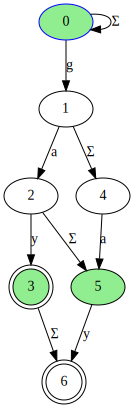

True

In [ ]:
import string

class InserirShiftAndAutomato:

    def __init__(self, PADRAO):
        self.PADRAO = PADRAO
        self.k = 1

        self.alfabeto = set(string.ascii_lowercase + " ")
        self.states = []
        self.delta = {}
        self.initial_state = 0
        self.final_states = set()
        self.construir_automato()

    def set_estados(self):
        self.states = list(range(2*len(self.PADRAO)+1))

    def set_transicoes(self):
        self.delta = {}
        p = self.PADRAO
        self.delta.setdefault((0, "Σ"), set()).add(0)


        # transição principal
        for i in range(len(p)):
            self.delta.setdefault((i, p[i]), set()).add(i+1)

        # transições extras (inserção)
        for i in range(1, len(p)):
            self.delta.setdefault((i+len(p), p[i]), set()).add(i+len(p)+1)

        # transição Σ
        for i in range(1, len(p)+1):
          self.delta.setdefault((i, "Σ"), set()).add(len(p)+i)


    def set_finais(self):
        self.final_states.add(len(self.PADRAO))
        self.final_states.add(len(self.states)-1)

    def construir_automato(self):
        self.set_estados()
        self.set_transicoes()
        self.set_finais()

    def aceita(self, texto: str):
        atuais = {self.initial_state}

        for caractere in texto:
            if caractere not in self.alfabeto:
                return False

            novos = set()

            for estado in atuais:
                novos |= set(self.delta.get((estado, caractere), []))
                novos |= set(self.delta.get((estado, "Σ"), []))

            atuais = novos
        return any(e in self.final_states for e in atuais)




p=InserirShiftAndAutomato("gay")
animar(p,"reali eh gay")


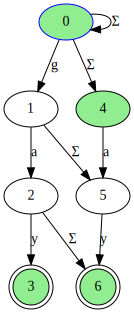

True

In [ ]:
class SubstituirShiftAndAutomato:

    def __init__(self, PADRAO):
        self.PADRAO = PADRAO
        self.k = 1

        self.alfabeto = set(string.ascii_lowercase + " ")
        self.states = []
        self.delta = {}
        self.initial_state = 0
        self.final_states = set()
        self.construir_automato()

    def set_estados(self):
        self.states = list(range(2*len(self.PADRAO)+1))

    def set_transicoes(self):
        self.delta = {}
        p = self.PADRAO
        self.delta.setdefault((0, "Σ"), set()).add(0)


        # transição principal
        for i in range(len(p)):
            self.delta.setdefault((i, p[i]), set()).add(i+1)

        # transição secundária (substituição)
        for i in range(1, len(p)):
            self.delta.setdefault((i+len(p), p[i]), set()).add(i+len(p)+1)

        # transição Σ
        for i in range(len(p)):
            self.delta.setdefault((i, "Σ"), set()).add(len(p)+i+1)



    def set_finais(self):
        self.final_states.add(len(self.PADRAO))
        self.final_states.add(len(self.states)-1)

    def construir_automato(self):
        self.set_estados()
        self.set_transicoes()
        self.set_finais()

    def aceita(self, texto: str):
        atuais = {self.initial_state}

        for caractere in texto:
            if caractere not in self.alfabeto:
                return False

            novos = set()

            for estado in atuais:
                novos |= set(self.delta.get((estado, caractere), []))
                novos |= set(self.delta.get((estado, "Σ"), []))

            atuais = novos
        return any(e in self.final_states for e in atuais)




p2=SubstituirShiftAndAutomato("gay")
animar(p2,"reali eh gay")


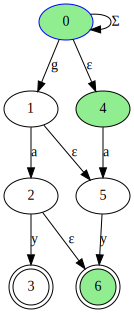

True

In [ ]:
import string as _string  # para evitar sobrescrita de nomes no escopo acima


class DeletarShiftAndAutomato:
    def __init__(self, PADRAO):
        self.PADRAO = PADRAO
        self.k = 1

        self.alfabeto = set(_string.ascii_lowercase + " ")
        self.states = []
        self.delta = {}
        self.initial_state = 0
        self.final_states = set()
        self.construir_automato()

    def set_estados(self):
        self.states = list(range(2 * len(self.PADRAO) + 1))

    def set_transicoes(self):
        self.delta = {}
        p = self.PADRAO

        self.delta.setdefault((0, "Σ"), set()).add(0)

        # transição principal
        for i in range(len(p)):
            self.delta.setdefault((i, p[i]), set()).add(i + 1)

        # transição após erro
        for i in range(1, len(p)):
            self.delta.setdefault((i + len(p), p[i]), set()).add(i + len(p) + 1)

        # transições ε: saltar do estado i para a trilha pós-erro (simula deleção)
        for i in range(len(p)):
            self.delta.setdefault((i, EPS), set()).add(i + len(p) + 1)

    def set_finais(self):
        self.final_states.add(len(self.PADRAO))
        self.final_states.add(len(self.states) - 1)

    def construir_automato(self):
        self.set_estados()
        self.set_transicoes()
        self.set_finais()

    def epsilon_fecho(self, estados):
        # calcula ε-fecho
        pilha = list(estados)
        fecho = set(estados)

        while pilha:
            e = pilha.pop()
            for d in self.delta.get((e, EPS), []):
                if d not in fecho:
                    fecho.add(d)
                    pilha.append(d)

        return fecho

    def aceita(self, texto: str):
        atuais = self.epsilon_fecho({self.initial_state})

        for caractere in texto:
            if caractere not in self.alfabeto:
                return False

            novos = set()

            for estado in atuais:
                novos |= self.delta.get((estado, caractere), set())
                novos |= self.delta.get((estado, "Σ"), set())

            atuais = self.epsilon_fecho(novos)

        return any(e in self.final_states for e in atuais)




p3=DeletarShiftAndAutomato("gay")
animar(p3,"reali eh gay")


In [ ]:
class ShiftAnd:
    """
    Controlador de vários autômatos:
    - aceita(texto): True se qualquer autômato aceitar (A1 ∪ A2 ∪ A3)
    - animar_varios(texto,...): anima os autômatos lado a lado (SVG), mostrando True/False por passo.
    """

    def __init__(self, *automatos, default_delay: float = 0.8):
        self.automatos = automatos
        self.default_delay = default_delay
    def set_padrao_geral(self, padrao):
      for i in self.automatos:
        i.PADRAO = padrao


    def aceita(self, texto: str) -> bool:
        """
        Retorna True se qualquer autômato aceitar o texto.
        Usa o método aceita() de cada autômato.
        """
        return any(a.aceita(texto) for a in self.automatos)

    def animar_varios(self, texto: str, delay: float | None = None, show_states: bool = False, max_width: int = 360) -> bool:
        """
        Anima os autômatos lado a lado.
        Parâmetros:
          - texto: string a ser lida (cada caractere = um passo)
          - delay: segundos entre frames. Se None, usa self.default_delay.
          - show_states: se True, mostra também a lista de estados ativos por autômato
          - max_width: largura máxima do SVG para cada autômato (ajuste para sua tela)
        Retorna True se qualquer autômato aceitar ao final.
        """
        if delay is None:
            delay = self.default_delay

        estados = [
            a.epsilon_fecho({a.initial_state}) if hasattr(a, "epsilon_fecho")
            else {a.initial_state}
            for a in self.automatos
        ]

        for idx, ch in enumerate(texto):
            clear_output(wait=True)

            display(_html_palavra_com_cursor(texto, idx))
            display(HTML(f"<div style='font-family:monospace; color:#666; margin-bottom:6px;'>Lendo índice {idx} → '{ch}'</div>"))

            html = "<div style='display:flex; gap:20px; align-items:flex-start; justify-content:space-around;'>"

            novos_estados = []

            for i, a in enumerate(self.automatos):
                g = Digraph(format="svg")

                for s in a.states:
                    attrs = {}
                    if s in a.final_states:
                        attrs["shape"] = "doublecircle"
                    if s == a.initial_state:
                        attrs["color"] = "blue"
                    if s in estados[i]:
                        attrs["style"] = "filled"
                        attrs["fillcolor"] = "lightgreen"
                    g.node(str(s), **attrs)

                novos = set()
                for (orig, simb), destinos in a.delta.items():
                    for d in destinos:
                        cor = "black"
                        if orig in estados[i] and simb in (ch, "Σ"):
                            cor = "red"
                            novos.add(d)
                        if simb == EPS:
                            cor = "gray"
                        g.edge(str(orig), str(d), label=simb, color=cor)

                svg = g.pipe().decode("utf-8")
                svg = svg.replace("<svg ", f'<svg style="max-width:{max_width}px;height:auto;" ')

                # calcula próximos estados
                proximos = a.epsilon_fecho(novos) if hasattr(a, "epsilon_fecho") else novos
                novos_estados.append(proximos)

                aceitou_agora = any(s in a.final_states for s in proximos)

                status_html = ("<span style='color:green;font-weight:700;'>True</span>"
                               if aceitou_agora else
                               "<span style='color:red;font-weight:700;'>False</span>")

                titulo = getattr(a, "PADRAO", f"Autômato {i+1}")

                # lista de estados ativos (opcional)
                estados_html = ""
                if show_states:
                    lst = sorted(proximos)
                    estados_html = f"<div style='margin-top:4px; font-family:monospace; color:#333;'>Estados: {lst}</div>"

                # bloco dos autômatos
                html += f"""
                <div style="flex:1 0 0; max-width:{max_width}px; text-align:center;">
                    <div style="font-weight:700; margin-bottom:6px;">{titulo}</div>
                    <div style="border:1px solid #eee; padding:6px; background:#fff;">
                        {svg}
                    </div>
                    <div style="margin-top:6px; font-family:monospace;">
                        Aceita agora: {status_html}
                        {estados_html}
                    </div>
                </div>
                """

            html += "</div>"

            display(HTML(html))

            estados = novos_estados

            time.sleep(delay)

        clear_output(wait=True)
        display(_html_palavra_com_cursor(texto, len(texto) - 1 if texto else 0))
        display(HTML("<div style='font-family:monospace; color:#666; margin-bottom:6px;'>Fim da leitura</div>"))

        # mostra estado final (todos os autômatos)
        final_html = "<div style='display:flex; gap:20px; align-items:flex-start; justify-content:space-around; margin-top:8px;'>"
        for i, a in enumerate(self.automatos):
            aceitou = any(s in a.final_states for s in estados[i])
            status_html = ("<span style='color:green;font-weight:700;'>True</span>"
                           if aceitou else "<span style='color:red;font-weight:700;'>False</span>")
            titulo = getattr(a, "PADRAO", f"Autômato {i+1}")
            final_html += f"""
            <div style="flex:1 0 0; max-width:{max_width}px; text-align:center;">
                <div style="font-weight:700; margin-bottom:6px;">{titulo}</div>
                <div style="font-family:monospace;">Aceitou no final: {status_html}</div>
            </div>
            """
        final_html += "</div>"
        display(HTML(final_html))

        # retorna True se algum autômato aceitou no final
        return any(any(s in a.final_states for s in estados[i]) for i, a in enumerate(self.automatos))


s = ShiftAnd(p, p2, p3, default_delay=1.5)
s.animar_varios("reali eh gay", delay=None, show_states=True)

True